# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [1]:
# Uncomment and run if required
!pip install transformers torchvision torch accelerate

   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.8 MB 991.0 kB/s eta 0:00:04
   - -------------------------------------- 0.2/3.8 MB 2.3 MB/s eta 0:00:02
   ----- ---------------------------------- 0.5/3.8 MB 4.5 MB/s eta 0:00:01
   ------------ --------------------------- 1.2/3.8 MB 7.5 MB/s eta 0:00:01
   ------------------------ --------------- 2.4/3.8 MB 12.6 MB/s eta 0:00:01
   -------------------------------------- - 3.7/3.8 MB 15.6 MB/s eta 0:00:01
   ---------------------------------------  3.8/3.8 MB 15.2 MB/s eta 0:00:01
   ---------------------------------------- 3.8/3.8 MB 12.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/122.0 MB ? eta -:--:--
    --------------------------------------- 1.6/122.0 MB 49.9 MB/s eta 0:00:03
   - -------------------------------------- 3.4/122.0 MB 44.0 MB/s eta 0:00:03
   - -------------------------------------- 4.5/122.0 MB 36.0 MB/s eta 0:00:04
   -- ---


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\h_daw\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

Using device: cpu


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [3]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,       # Load the test split
    download=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_clip
)

If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

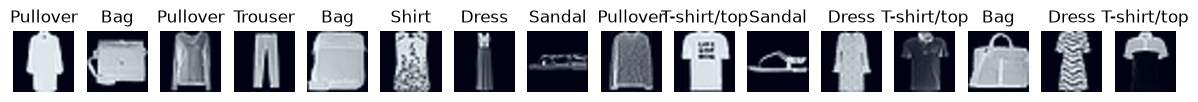

In [4]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [5]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """
    Get normalized CLIP text embeddings for the supplied class names.

    Args:
        class_names: Class descriptions to encode.

    Returns:
        Normalized text embeddings.
    """
    tokenized = clip_processor(
        text=class_names,
        padding=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output = clip_model.get_text_features(**tokenized)

    # Handle different Transformers return formats
    if isinstance(output, torch.Tensor):
        text_feats = output

    elif hasattr(output, "pooler_output"):
        # Extract pooled features and apply CLIP's text projection
        text_feats = clip_model.text_projection(output.pooler_output)

    else:
        raise TypeError(
            f"Unexpected output type from get_text_features: {type(output)}"
        )

    # Normalize the text embeddings
    text_feats = text_feats / text_feats.norm(
        dim=-1,
        keepdim=True
    ).clamp(min=1e-12)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images)

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [6]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors

    cosine_similarity = image_feats @ text_feats.T

    return cosine_similarity.numpy()
    

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    return np.argmax(similarity, axis=1)

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Build text embeddings once
text_embeddings = get_text_embeddings(CLASS_NAMES)

y_true, y_pred = [], []

for pixel_values, labels in test_loader:

        # Create normalized image embeddings
    image_embeddings = get_image_embeddings(pixel_values)

    # Compute similarity between each image and each class name
    similarity = get_cosine_similarity(
        image_embeddings,
        text_embeddings
    )

    # Get the predicted class for each image
    predictions = get_predictions(similarity)

    # Save true labels and predictions
    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

# Report the accuracy of the predictions
accuracy = accuracy_score(y_true, y_pred)

print(f"Zero-shot classification accuracy: {accuracy:.4f}")
print(f"Zero-shot classification accuracy: {accuracy:.2%}")

# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

Zero-shot classification accuracy: 0.6240
Zero-shot classification accuracy: 62.40%


Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?



Simple CNN performance
----------------------
Test accuracy: 0.9102
Test accuracy percentage: 91.02%

Zero-shot classification performance
----------------------
Zero-shot classification accuracy: 0.6240
Zero-shot classification accuracy: 62.40%

The zero-shot classifier performed noticeably worse than the CNN model trained in Assignment 1 as depicted by results above. The CNN was trained directly on the FashionMNIST dataset, allowing it to learn the visual characteristics of each clothing category from thousands of labeled examples. As a result, it achieved much higher classification accuracy than the zero-shot model.

In contrast, zero-shot was not trained specifically on FashionMNIST. Instead, it relies on matching image embeddings with text descriptions such as "T-shirt/top" or "Sneaker." Although this allows zero-shot to classify images without any task-specific training, its performance is limited when class names are ambiguous or visually similar. For example, categories such as Shirt, T-shirt/top, Pullover, and Coat often have overlapping visual features, leading to more misclassifications in the confusion matrix.

One of the greatest strengths of the zero-shot approach is that it requires no additional training data or model fine-tuning. It can immediately classify images using only natural language descriptions, making it highly flexible and useful for tasks where labeled data is unavailable or new classes are introduced. This significantly reduces the time and computational resources required to deploy a model.

However, the main weakness is its lower accuracy on specialized datasets compared to a supervised model trained for the same task. The CNN learns dataset-specific features and decision boundaries, making it more reliable for FashionMNIST classification. Overall, while the CNN is the better choice for achieving high accuracy on a known dataset, zero-shot demonstrates the powerful capability of transferring knowledge to new tasks without any additional training, illustrating the trade-off between flexibility and predictive performance.

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# More descriptive prompts for each FashionMNIST class.
# The order must match the numeric labels in CLASS_NAMES.
IMPROVED_PROMPTS = [
    "a grayscale image of a short-sleeved T-shirt or casual top",
    "a grayscale image of a pair of long trousers or pants",
    "a grayscale image of a knitted pullover sweater with long sleeves",
    "a grayscale image of a one-piece dress",
    "a grayscale image of a heavy coat or jacket with long sleeves",
    "a grayscale image of an open sandal showing parts of the foot",
    "a grayscale image of a collared button-up shirt",
    "a grayscale image of a closed athletic sneaker or running shoe",
    "a grayscale image of a handbag or shoulder bag",
    "a grayscale image of a high ankle boot covering the ankle"
]

# Display the prompts
for class_name, prompt in zip(CLASS_NAMES, IMPROVED_PROMPTS):
    print(f"{class_name}: {prompt}")

T-shirt/top: a grayscale image of a short-sleeved T-shirt or casual top
Trouser: a grayscale image of a pair of long trousers or pants
Pullover: a grayscale image of a knitted pullover sweater with long sleeves
Dress: a grayscale image of a one-piece dress
Coat: a grayscale image of a heavy coat or jacket with long sleeves
Sandal: a grayscale image of an open sandal showing parts of the foot
Shirt: a grayscale image of a collared button-up shirt
Sneaker: a grayscale image of a closed athletic sneaker or running shoe
Bag: a grayscale image of a handbag or shoulder bag
Ankle boot: a grayscale image of a high ankle boot covering the ankle


In [9]:
# Improved Text enbeddings
improved_text_embeddings = get_text_embeddings(IMPROVED_PROMPTS)

print("Improved text embeddings shape:",
      improved_text_embeddings.shape)

Improved text embeddings shape: torch.Size([10, 512])


In [10]:
#Run zero-shot classification again:
improved_y_true = []
improved_y_pred = []

for pixel_values, labels in test_loader:

    # Create image embeddings for the current batch
    image_embeddings = get_image_embeddings(pixel_values)

    # Compare image embeddings with improved text embeddings
    similarity = get_cosine_similarity(
        image_embeddings,
        improved_text_embeddings
    )

    # Select the class with the highest similarity
    predictions = get_predictions(similarity)

    # Save labels and predictions for evaluation
    improved_y_true.extend(labels.numpy())
    improved_y_pred.extend(predictions)

In [11]:
improved_accuracy = accuracy_score(
    improved_y_true,
    improved_y_pred
)

print(
    f"Improved prompt accuracy: "
    f"{improved_accuracy:.4f}"
)

print(
    f"Improved prompt accuracy: "
    f"{improved_accuracy:.2%}"
)

Improved prompt accuracy: 0.6376
Improved prompt accuracy: 63.76%



Improved Prompt Confusion Matrix:
[[749   1  32 126   1   9   9   0  73   0]
 [  0 886   3  39   1  62   0   0   5   4]
 [ 21   2 851  22   8   0   1   0  95   0]
 [ 58  26  29 650  16  58   3   0 156   4]
 [ 11   7 529  70 251   2  22   0 107   1]
 [  0  24   0   0   0 125   0 598 138 115]
 [178   6 368 118  95   6 112   0 116   1]
 [  0   0   0   0   0   2   0 988   2   8]
 [  0   0   0   0   0   1   0   4 995   0]
 [  0   0   0   0   0   4   0 226   1 769]]


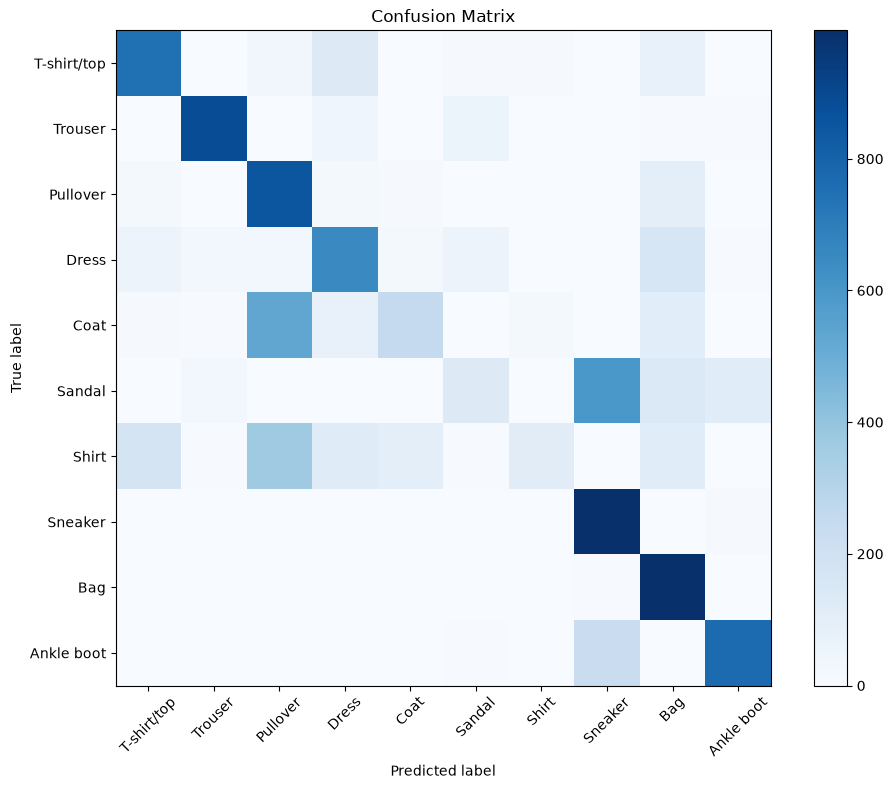

In [12]:
improved_cm = confusion_matrix(
    improved_y_true,
    improved_y_pred
)

print("\nImproved Prompt Confusion Matrix:")
print(improved_cm)

plot_confusion_matrix(
    improved_y_true,
    improved_y_pred,
    CLASS_NAMES
)

In [13]:
baseline_accuracy = accuracy_score(y_true, y_pred)

print("Zero-shot performance comparison")
print("-" * 40)
print(f"Original class-name prompts: {baseline_accuracy:.2%}")
print(f"Improved detailed prompts:   {improved_accuracy:.2%}")

difference = improved_accuracy - baseline_accuracy

if difference > 0:
    print(f"Accuracy improvement:        {difference:.2%}")
elif difference < 0:
    print(f"Accuracy decreased by:       {abs(difference):.2%}")
else:
    print("The accuracy did not change.")

Zero-shot performance comparison
----------------------------------------
Original class-name prompts: 62.40%
Improved detailed prompts:   63.76%
Accuracy improvement:        1.36%


In [17]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Prompt approach": [
        "Original class names",
        "Improved descriptive prompts"
    ],
    "Accuracy": [
        baseline_accuracy,
        improved_accuracy
    ]
})

# Accuracy as percentage
comparison_df["Accuracy (%)"] = (
    comparison_df["Accuracy"] * 100
).round(2)

# Improvement relative to the baseline
comparison_df["Accuracy Improvement (%)"] = [
    0.00,
    round((improved_accuracy - baseline_accuracy) * 100, 2)
]

comparison_df

,Prompt approach,Accuracy,Accuracy (%),Accuracy Improvement (%)
0,Original class names,0.6240,62.40,0.00
1,Improved descriptive prompts,0.6376,63.76,1.36


Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

Using more detailed prompts resulted in a small improvement in the zero-shot classification performance. The baseline model achieved an accuracy of 62.40%, while the improved descriptive prompts increased the accuracy to 63.76%, representing an improvement of 1.36 percentage points. Although the improvement was modest, it demonstrates that prompt engineering can positively influence the performance of a zero-shot model without requiring any additional training.

The confusion matrix indicated that the model continued to confuse visually similar clothing categories, particularly T-shirt/top, Shirt, Pullover, and Coat. These items share common visual characteristics, making them difficult to distinguish using only simple text descriptions. The improved prompts provided additional context, such as sleeve length, garment type, and intended use, which helped the model better align the image and text representations for some classes. However, the improvement was limited because FashionMNIST consists of low-resolution grayscale images with relatively little visual detail, making fine-grained distinctions inherently challenging.

This experiment highlights both the strengths and limitations of CLIP's zero-shot learning capability. A major strength is that the model can classify images without any task-specific training, relying solely on natural language prompts. This makes it highly flexible and adaptable to new tasks. However, its performance remains lower than a supervised CNN trained directly on the FashionMNIST dataset, which learns features specifically optimized for these classes.

With additional effort, the performance could likely be improved further. More descriptive prompts could include information about garment materials, shapes, collars, sleeve lengths, footwear style, and typical usage. Another strategy would be to use multiple prompts for each class (prompt ensembling), such as combining descriptions like "a photo of a knitted sweater" and "a grayscale image of a pullover," then averaging their embeddings. Fine-tuning CLIP on FashionMNIST or using a higher-resolution fashion dataset would likely produce even greater improvements. Overall, this exercise demonstrates that prompt engineering can improve zero-shot classification performance, but there are practical limits compared to models that are trained directly on the target dataset.

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [19]:
# Uncomment the following line to install UMAP if you haven't already
!pip install umap-learn

   ---------------------------------------- 0.0/91.8 kB ? eta -:--:--
   ------------- -------------------------- 30.7/91.8 kB 660.6 kB/s eta 0:00:01
   ---------------------------------------- 91.8/91.8 kB 1.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/73.5 kB ? eta -:--:--
   ---------------------------------------- 73.5/73.5 kB 4.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\h_daw\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


100%|██████████| 625/625 [10:09<00:00,  1.03it/s]
c:\Users\h_daw\deeplearning\deep_learning\deep-learning-env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Image embeddings shape: (10000, 512)
Labels shape: (10000,)


c:\Users\h_daw\deeplearning\deep_learning\deep-learning-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D embeddings shape: (10000, 2)


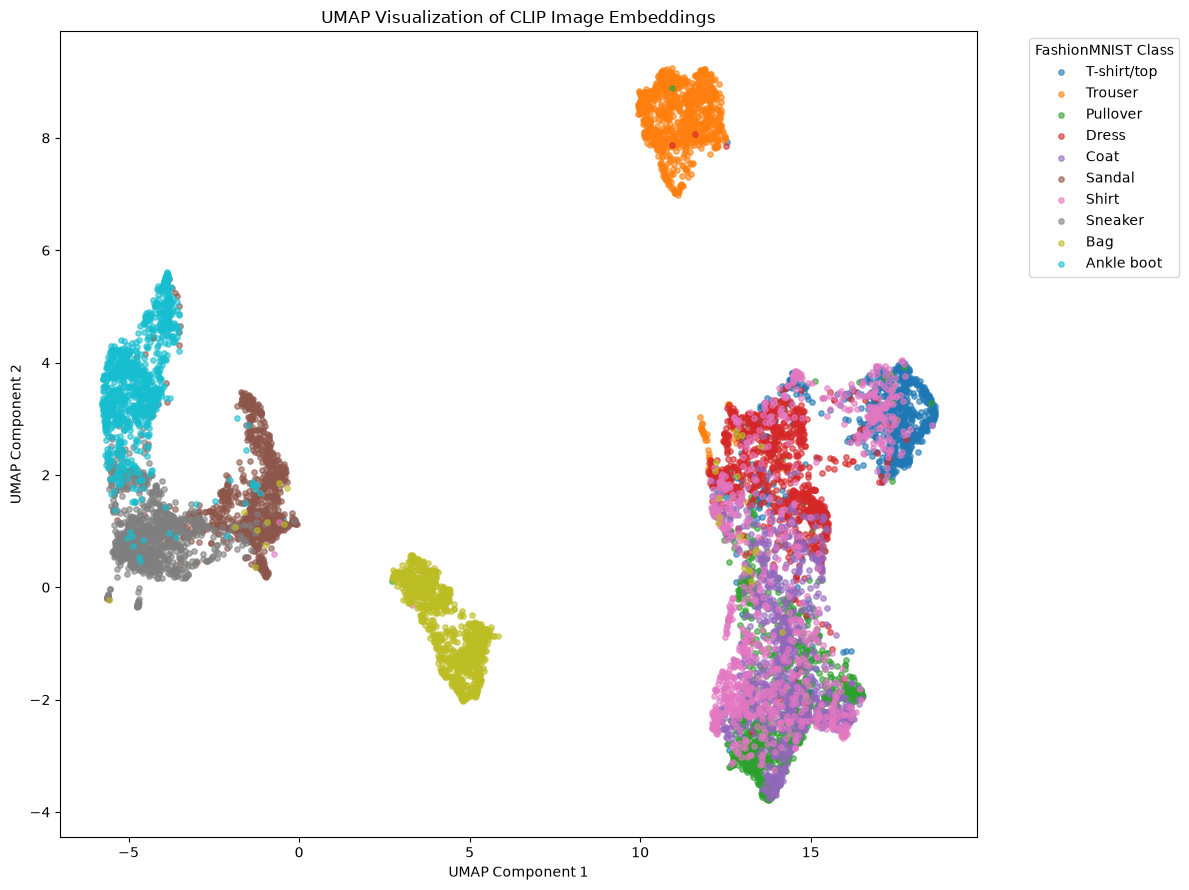

In [20]:
from umap import UMAP
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

#for pixel_values, labels in test_loader:
from tqdm import tqdm
for pixel_values, labels in tqdm(test_loader):

      # Generate normalized image embeddings for the batch
    image_embeddings = get_image_embeddings(pixel_values)

    # Move embeddings to CPU and convert to NumPy
    all_img_emb.append(
        image_embeddings.detach().cpu().numpy()
    )

    # Save the true labels
    all_labels.append(
        labels.cpu().numpy()
    )

# Combine all batches into single arrays
all_img_emb = np.concatenate(all_img_emb, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print("Image embeddings shape:", all_img_emb.shape)
print("Labels shape:", all_labels.shape)

# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------
umap_model = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embeddings_2d = umap_model.fit_transform(all_img_emb)

print("2D embeddings shape:", embeddings_2d.shape)

# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------
plt.figure(figsize=(12, 9))

for class_index, class_name in enumerate(CLASS_NAMES):

    # Select points belonging to the current class
    class_mask = all_labels == class_index

    plt.scatter(
        embeddings_2d[class_mask, 0],
        embeddings_2d[class_mask, 1],
        label=class_name,
        alpha=0.6,
        s=15
    )

plt.title("UMAP Visualization of CLIP Image Embeddings")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend(
    title="FashionMNIST Class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?

The UMAP visualization shows that some clothing categories form well-defined clusters, while others overlap considerably. This indicates that the CLIP image embeddings are able to capture meaningful visual similarities between images, but some classes remain difficult to separate based on their appearance alone.

The greatest challenge is distinguishing clothing items with similar shapes and textures. Classes such as T-shirt/top, Shirt, Pullover, and Coat tend to overlap because they all represent upper-body garments with comparable silhouettes, especially in the low-resolution grayscale FashionMNIST images. As a result, the embeddings for these classes are located close together, making them more difficult for the model to distinguish.

In contrast, classes such as Bag, Ankle boot, Sneaker, and Sandal typically form more distinct clusters. These items have unique shapes that differ significantly from the clothing categories and from one another. For example, bags have a compact rectangular appearance, while sandals, sneakers, and ankle boots have distinctive footwear outlines. Their visual uniqueness allows the model to generate embeddings that are more clearly separated in the UMAP projection.

Overall, the visualization demonstrates that CLIP learns meaningful semantic representations even without being trained specifically on FashionMNIST. Images belonging to the same class are generally grouped together, suggesting that the model captures high-level visual features. However, classes with subtle visual differences remain difficult to separate because of the limited image resolution and the similarity between garment types. These observations are consistent with the confusion matrices obtained during the zero-shot classification experiments, where the greatest number of misclassifications occurred between visually similar upper-body clothing categories.

## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

In [ ]:
#A - Alternative Model
#1. Load the alternative model
from transformers import CLIPModel, CLIPProcessor
import torch
import numpy as np
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Alternative larger CLIP model
alternative_model_name = "openai/clip-vit-large-patch14"

alternative_model = CLIPModel.from_pretrained(
    alternative_model_name
)

alternative_processor = CLIPProcessor.from_pretrained(
    alternative_model_name,
    use_fast=False
)

alternative_model.eval()
alternative_model.to(device)

print(f"Loaded model: {alternative_model_name}")
print(f"Using device: {device}")

Loaded model: openai/clip-vit-large-patch14
Using device: cpu


In [25]:
#2. Create a separate collate function

def collate_alternative_clip(batch):
    """
    Process a batch of FashionMNIST images using the
    alternative CLIP processor.
    """
    images, labels = zip(*batch)

    processed = alternative_processor(
        images=list(images),
        return_tensors="pt",
        padding=True
    )

    pixel_values = processed["pixel_values"].to(device)
    labels = torch.tensor(labels)

    return pixel_values, labels

In [26]:
#Create a new DataLoader:
alternative_test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_alternative_clip
)

In [27]:
#3. Create helper functions for the new model
def get_alternative_text_embeddings(
    prompts: list[str]
) -> torch.Tensor:
    """
    Create normalized text embeddings using the alternative model.
    """
    tokenized = alternative_processor(
        text=prompts,
        padding=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        text_embeddings = alternative_model.get_text_features(
            **tokenized
        )

    # Compatibility with Transformers versions that return
    # either a Tensor or a structured model output
    if not isinstance(text_embeddings, torch.Tensor):
        if hasattr(text_embeddings, "pooler_output"):
            text_embeddings = alternative_model.text_projection(
                text_embeddings.pooler_output
            )
        else:
            raise TypeError(
                "Unexpected text output type: "
                f"{type(text_embeddings)}"
            )

    text_embeddings = text_embeddings / text_embeddings.norm(
        dim=-1,
        keepdim=True
    ).clamp(min=1e-12)

    return text_embeddings


def get_alternative_image_embeddings(
    pixel_values: torch.Tensor
) -> torch.Tensor:
    """
    Create normalized image embeddings using the alternative model.
    """
    with torch.no_grad():
        image_embeddings = alternative_model.get_image_features(
            pixel_values=pixel_values
        )

    # Compatibility with Transformers versions that return
    # either a Tensor or a structured model output
    if not isinstance(image_embeddings, torch.Tensor):
        if hasattr(image_embeddings, "pooler_output"):
            image_embeddings = alternative_model.visual_projection(
                image_embeddings.pooler_output
            )
        else:
            raise TypeError(
                "Unexpected image output type: "
                f"{type(image_embeddings)}"
            )

    image_embeddings = image_embeddings / image_embeddings.norm(
        dim=-1,
        keepdim=True
    ).clamp(min=1e-12)

    return image_embeddings

In [28]:
#4. Select the prompts

ALTERNATIVE_PROMPTS = [
    "a grayscale image of a short-sleeved T-shirt or casual top",
    "a grayscale image of a pair of long trousers or pants",
    "a grayscale image of a knitted pullover sweater with long sleeves",
    "a grayscale image of a one-piece dress",
    "a grayscale image of a heavy coat or jacket with long sleeves",
    "a grayscale image of an open sandal showing parts of the foot",
    "a grayscale image of a collared button-up shirt",
    "a grayscale image of a closed athletic sneaker or running shoe",
    "a grayscale image of a handbag or shoulder bag",
    "a grayscale image of a high ankle boot covering the ankle"
]

In [29]:
#5. Test one batch first
alternative_text_embeddings = (
    get_alternative_text_embeddings(ALTERNATIVE_PROMPTS)
)

pixel_values, labels = next(
    iter(alternative_test_loader)
)

alternative_image_embeddings = (
    get_alternative_image_embeddings(pixel_values)
)

print(
    "Text embeddings shape:",
    alternative_text_embeddings.shape
)

print(
    "Image embeddings shape:",
    alternative_image_embeddings.shape
)

Text embeddings shape: torch.Size([10, 768])
Image embeddings shape: torch.Size([16, 768])


In [30]:
#6. Run zero-shot classification
# Text embeddings only need to be calculated once
alternative_text_embeddings = (
    get_alternative_text_embeddings(ALTERNATIVE_PROMPTS)
)

alternative_y_true = []
alternative_y_pred = []

for batch_number, (pixel_values, labels) in enumerate(
    alternative_test_loader,
    start=1
):
    # Generate image embeddings
    image_embeddings = get_alternative_image_embeddings(
        pixel_values
    )

    # Compute cosine similarity
    similarity = get_cosine_similarity(
        image_embeddings,
        alternative_text_embeddings
    )

    # Select the class with the highest similarity
    predictions = get_predictions(similarity)

    # Save labels and predictions
    alternative_y_true.extend(labels.numpy())
    alternative_y_pred.extend(predictions)

    # Optional progress display
    if batch_number % 100 == 0:
        print(
            f"Processed {batch_number}/"
            f"{len(alternative_test_loader)} batches"
        )

Processed 100/625 batches
Processed 200/625 batches
Processed 300/625 batches
Processed 400/625 batches
Processed 500/625 batches
Processed 600/625 batches


In [31]:
#7. Rerport accuracy
alternative_accuracy = accuracy_score(
    alternative_y_true,
    alternative_y_pred
)

print(
    f"Alternative model accuracy: "
    f"{alternative_accuracy:.2%}"
)

Alternative model accuracy: 65.39%


Alternative model confusion matrix:
[[681  16   2 247   1   4  17  15  17   0]
 [  0 982   0  18   0   0   0   0   0   0]
 [135  69 425 125 138   0   4  16  88   0]
 [  7  68   2 863  30   3   1   5  20   1]
 [  8  26  57  97 691   1  82   3  35   0]
 [  0  40   0   0   0 106   0 527 108 219]
 [183  55  95 209 239   0 169   1  48   1]
 [  0   1   0   0   0  10   0 980   1   8]
 [  0  68   0   1   1   3   2  26 899   0]
 [  0   1   0   0   0   1   0 255   0 743]]


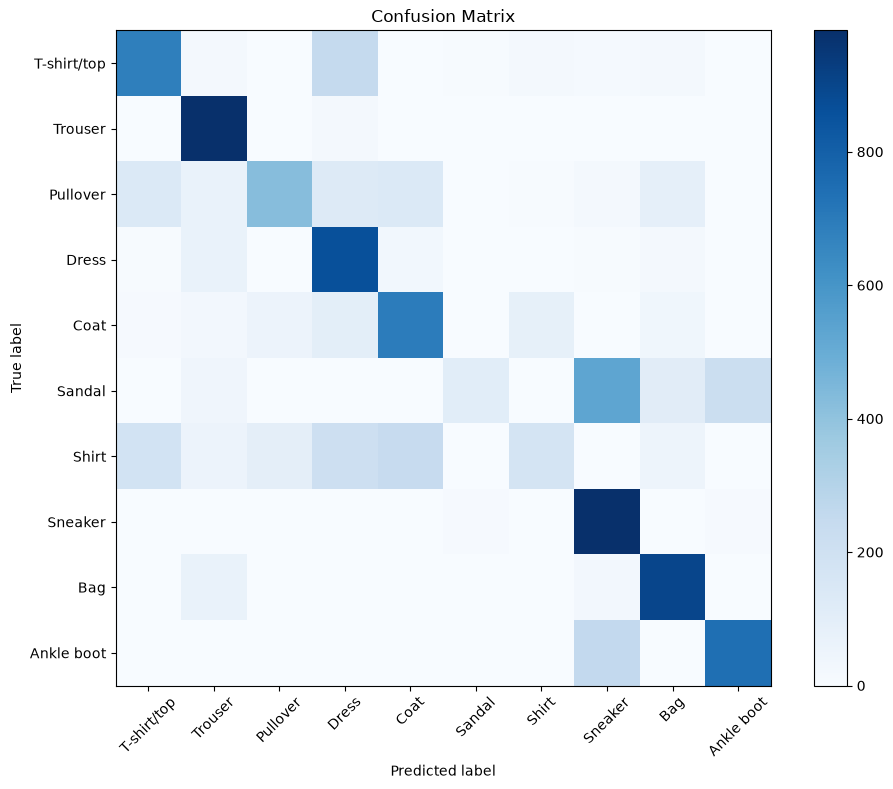

In [32]:
#Display the confusion matrix

alternative_cm = confusion_matrix(
    alternative_y_true,
    alternative_y_pred
)

print("Alternative model confusion matrix:")
print(alternative_cm)

plot_confusion_matrix(
    alternative_y_true,
    alternative_y_pred,
    CLASS_NAMES
)

In [35]:
#9. Compare the results
import pandas as pd

# Use 0.6240 when comparing class-name prompts.
# Use 0.6376 when comparing improved prompts.
original_comparison_accuracy = improved_accuracy

model_comparison_df = pd.DataFrame({
    "Model": [
        "Original Model & Improved prompts-CLIP ViT-B/32",
        "Alternative Model- CLIP ViT-L/14"
    ],
    "Accuracy": [
        original_comparison_accuracy,
        alternative_accuracy
    ]
})

model_comparison_df["Accuracy (%)"] = (
    model_comparison_df["Accuracy"] * 100
).round(2)

model_comparison_df["Difference from original (%)"] = (
    (
        model_comparison_df["Accuracy"]
        - original_comparison_accuracy
    ) * 100
).round(2)

model_comparison_df

,Model,Accuracy,Accuracy (%),Difference from original (%)
0,Original Model & Improved prompts-CLIP ViT-B/32,0.6376,63.76,0.00
1,Alternative Model- CLIP ViT-L/14,0.6539,65.39,1.63


In [36]:
#B. Multiple-Description Classification

from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import pandas as pd

#1. Create multiple prompts for each class
MULTIPLE_PROMPTS = {
    0: [
        "a photo of a short-sleeved T-shirt",
        "a photo of a casual top",
        "a grayscale image of a T-shirt"
    ],
    1: [
        "a photo of a pair of trousers",
        "a photo of long pants",
        "a grayscale image of trousers"
    ],
    2: [
        "a photo of a knitted pullover",
        "a photo of a long-sleeved sweater",
        "a grayscale image of a pullover"
    ],
    3: [
        "a photo of a one-piece dress",
        "a photo of a casual dress",
        "a grayscale image of a dress"
    ],
    4: [
        "a photo of a heavy coat",
        "a photo of a long-sleeved jacket",
        "a grayscale image of outerwear"
    ],
    5: [
        "a photo of an open sandal",
        "a photo of summer footwear with straps",
        "a grayscale image of a sandal"
    ],
    6: [
        "a photo of a collared shirt",
        "a photo of a button-up shirt",
        "a grayscale image of a long-sleeved shirt"
    ],
    7: [
        "a photo of an athletic sneaker",
        "a photo of a running shoe",
        "a grayscale image of a closed sports shoe"
    ],
    8: [
        "a photo of a handbag",
        "a photo of a shoulder bag",
        "a grayscale image of a bag with handles"
    ],
    9: [
        "a photo of an ankle boot",
        "a photo of a high-top boot",
        "a grayscale image of footwear covering the ankle"
    ]
}

In [38]:
# 2. Flatten the prompts and create a class mapping

all_prompts = []
prompt_to_class = []

for class_index in range(len(CLASS_NAMES)):
    for prompt in MULTIPLE_PROMPTS[class_index]:
        all_prompts.append(prompt)
        prompt_to_class.append(class_index)

prompt_to_class = np.array(prompt_to_class)

print("Number of prompts:", len(all_prompts))
print("Prompt-to-class mapping shape:", prompt_to_class.shape)

for prompt, class_index in zip(all_prompts, prompt_to_class):
    print(f"{CLASS_NAMES[class_index]:12s} -> {prompt}")

Number of prompts: 30
Prompt-to-class mapping shape: (30,)
T-shirt/top  -> a photo of a short-sleeved T-shirt
T-shirt/top  -> a photo of a casual top
T-shirt/top  -> a grayscale image of a T-shirt
Trouser      -> a photo of a pair of trousers
Trouser      -> a photo of long pants
Trouser      -> a grayscale image of trousers
Pullover     -> a photo of a knitted pullover
Pullover     -> a photo of a long-sleeved sweater
Pullover     -> a grayscale image of a pullover
Dress        -> a photo of a one-piece dress
Dress        -> a photo of a casual dress
Dress        -> a grayscale image of a dress
Coat         -> a photo of a heavy coat
Coat         -> a photo of a long-sleeved jacket
Coat         -> a grayscale image of outerwear
Sandal       -> a photo of an open sandal
Sandal       -> a photo of summer footwear with straps
Sandal       -> a grayscale image of a sandal
Shirt        -> a photo of a collared shirt
Shirt        -> a photo of a button-up shirt
Shirt        -> a grayscale i

In [39]:
#3. Create text embeddings

multiple_text_embeddings = get_text_embeddings(all_prompts)

print(
    "Multiple prompt embedding shape:",
    multiple_text_embeddings.shape
)

Multiple prompt embedding shape: torch.Size([30, 512])


In [40]:
#4. Run zero-shot classification
multiple_y_true = []
multiple_y_pred = []

for pixel_values, labels in test_loader:

    # Create image embeddings
    image_embeddings = get_image_embeddings(pixel_values)

    # Compare each image with all text prompts
    similarity = get_cosine_similarity(
        image_embeddings,
        multiple_text_embeddings
    )

    # Get the most similar prompt for each image
    predicted_prompt_indices = get_predictions(similarity)

    # Convert prompt predictions into class predictions
    predicted_classes = prompt_to_class[
        predicted_prompt_indices
    ]

    # Save true and predicted labels
    multiple_y_true.extend(labels.numpy())
    multiple_y_pred.extend(predicted_classes)

In [42]:
#5. Report accuracy

multiple_prompt_accuracy = accuracy_score(
    multiple_y_true,
    multiple_y_pred
)

print(
    f"Multiple-description accuracy: "
    f"{multiple_prompt_accuracy:.2%}"
)

Multiple-description accuracy: 68.15%


Multiple-description confusion matrix:
[[625   0  35 181   4  13  47   0  95   0]
 [  0 855   4  34   4  86   0   0  15   2]
 [  6   1 784  14  26   3  77   0  89   0]
 [ 19   9  17 723  22  79  23   0 108   0]
 [  3   4 444  64 308  10  77   0  90   0]
 [  0   3   2   0   9 616   0 234  17 119]
 [103   4 277 139  91  23 255   0 108   0]
 [  0   0   0   0   1  80   0 847   0  72]
 [  0   0   6   0  10  26   1   7 950   0]
 [  0   0   0   0   1  32   0 115   0 852]]


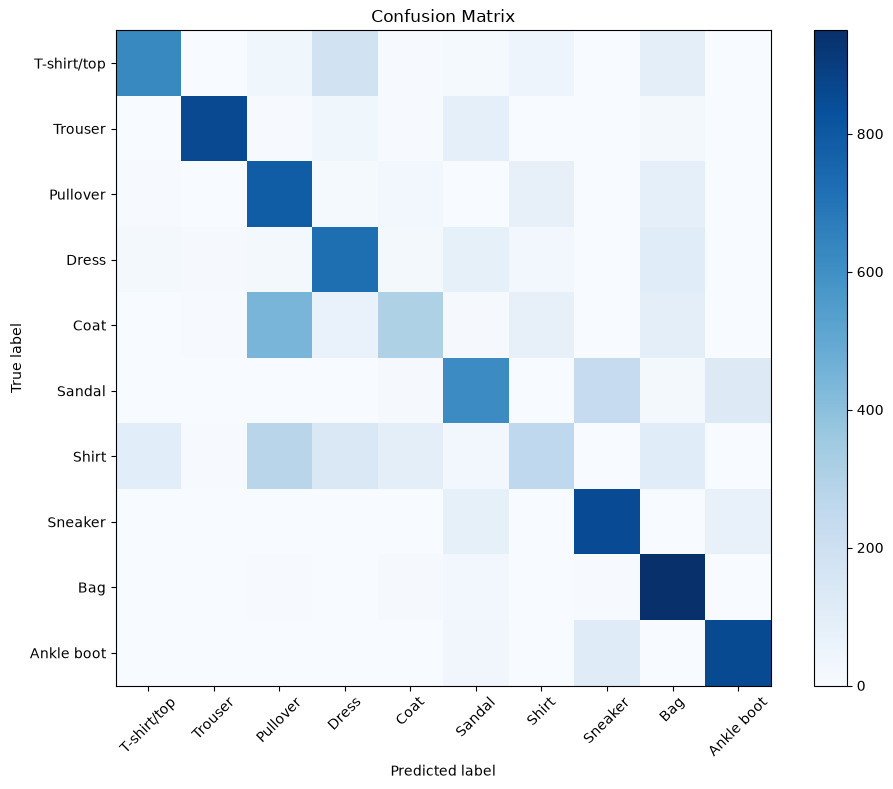

In [44]:
#6. Report and plot the confusion matrix

multiple_prompt_cm = confusion_matrix(
    multiple_y_true,
    multiple_y_pred
)

print("Multiple-description confusion matrix:")
print(multiple_prompt_cm)

plot_confusion_matrix(
    multiple_y_true,
    multiple_y_pred,
    CLASS_NAMES
)

In [47]:
##Compare all four experiments
comparison_df = pd.DataFrame({
    "Approach": [
        "Original CLIP ViT-B/32 with class-name prompts",
        "Original CLIP ViT-B/32 with detailed prompts",
        "Alternative CLIP ViT-L/14",
        "Original CLIP ViT-B/32 with multiple descriptions"
        
    ],
    "Accuracy": [
        baseline_accuracy,
        improved_accuracy,
        alternative_accuracy,
        multiple_prompt_accuracy
            ]
})

comparison_df["Accuracy (%)"] = (
    comparison_df["Accuracy"] * 100
).round(2)

comparison_df["Improvement over baseline (%)"] = (
    (
        comparison_df["Accuracy"]
        - baseline_accuracy
    ) * 100
).round(2)

comparison_df

,Approach,Accuracy,Accuracy (%),Improvement over baseline (%)
0,Original CLIP ViT-B/32 with class-name prompts,0.6240,62.40,0.00
1,Original CLIP ViT-B/32 with detailed prompts,0.6376,63.76,1.36
2,Alternative CLIP ViT-L/14,0.6539,65.39,2.99
3,Original CLIP ViT-B/32 with multiple descriptions,0.6815,68.15,5.75


In [ ]:
#C. Top-K Classification
#1. Modify get_predictions to return Top-K predictions

def get_top_k_predictions(similarity, k=2):
    """
    Return the indices of the top K predictions for each image.

    Parameters
    ----------
    similarity : torch.Tensor or np.ndarray
        Similarity scores with shape:
        (number_of_images, number_of_classes)

    k : int
        Number of highest-scoring classes to return.

    Returns
    -------
    np.ndarray
        Top-K predicted class indices with shape:
        (number_of_images, k)
    """
    if isinstance(similarity, torch.Tensor):
        similarity = similarity.detach().cpu().numpy()

    if k < 1 or k > similarity.shape[1]:
        raise ValueError(
            f"k must be between 1 and {similarity.shape[1]}"
        )

    # Sort scores from highest to lowest and keep the first K
    top_k_predictions = np.argsort(
        similarity,
        axis=1
    )[:, -k:][:, ::-1]

    return top_k_predictions

In [49]:
#2. Create a Top-K accuracy function
def calculate_top_k_accuracy(y_true, top_k_predictions):
    """
    Calculate accuracy based on whether the true class appears
    in the Top-K predictions.

    Parameters
    ----------
    y_true : array-like
        True class labels.

    top_k_predictions : np.ndarray
        Top-K predicted class indices with shape:
        (number_of_images, k)

    Returns
    -------
    float
        Top-K accuracy.
    """
    y_true = np.asarray(y_true)

    correct_predictions = [
        true_label in predicted_classes
        for true_label, predicted_classes
        in zip(y_true, top_k_predictions)
    ]

    return np.mean(correct_predictions)

In [50]:
#3. Run classification and collect similarity scores

all_top_k_labels = []
all_similarity_scores = []

for pixel_values, labels in test_loader:

    # Generate image embeddings
    image_embeddings = get_image_embeddings(pixel_values)

    # Compare image embeddings with text embeddings
    similarity = get_cosine_similarity(
        image_embeddings,
        improved_text_embeddings
    )

    # Save labels
    all_top_k_labels.extend(labels.cpu().numpy())

    # Save similarity scores
    if isinstance(similarity, torch.Tensor):
        similarity = similarity.detach().cpu().numpy()

    all_similarity_scores.append(similarity)

# Combine all batches
all_top_k_labels = np.asarray(all_top_k_labels)

all_similarity_scores = np.concatenate(
    all_similarity_scores,
    axis=0
)

print("Labels shape:", all_top_k_labels.shape)
print(
    "Similarity scores shape:",
    all_similarity_scores.shape
)

Labels shape: (10000,)
Similarity scores shape: (10000, 10)


In [51]:
#4. Calculate results for K=2 and K=4

top_2_predictions = get_top_k_predictions(
    all_similarity_scores,
    k=2
)

top_4_predictions = get_top_k_predictions(
    all_similarity_scores,
    k=4
)

top_2_accuracy = calculate_top_k_accuracy(
    all_top_k_labels,
    top_2_predictions
)

top_4_accuracy = calculate_top_k_accuracy(
    all_top_k_labels,
    top_4_predictions
)

print(f"Top-1 accuracy: {improved_accuracy:.2%}")
print(f"Top-2 accuracy: {top_2_accuracy:.2%}")
print(f"Top-4 accuracy: {top_4_accuracy:.2%}")

Top-1 accuracy: 63.76%
Top-2 accuracy: 80.70%
Top-4 accuracy: 92.56%


In [52]:
#5. Create a comparison table

top_k_comparison_df = pd.DataFrame({
    "K": [
        "Top-1",
        "Top-2",
        "Top-4"
    ],
    "Accuracy": [
        improved_accuracy,
        top_2_accuracy,
        top_4_accuracy
    ]
})

top_k_comparison_df["Accuracy (%)"] = (
    top_k_comparison_df["Accuracy"] * 100
).round(2)

top_k_comparison_df["Improvement over Top-1 (%)"] = (
    (
        top_k_comparison_df["Accuracy"]
        - improved_accuracy
    ) * 100
).round(2)

top_k_comparison_df[
    [
        "K",
        "Accuracy (%)",
        "Improvement over Top-1 (%)"
    ]
]

,K,Accuracy (%),Improvement over Top-1 (%)
0,Top-1,63.76,0.00
1,Top-2,80.70,16.94
2,Top-4,92.56,28.80


In [53]:
#6. Top-K confusion matrices

def get_top_k_confusion_predictions(
    y_true,
    top_k_predictions
):
    """
    Create one effective prediction per image for a Top-K
    confusion matrix.

    If the true label is in the Top-K predictions, the effective
    prediction is treated as correct.

    Otherwise, the model's first-ranked prediction is used.
    """
    y_true = np.asarray(y_true)
    effective_predictions = []

    for true_label, predicted_classes in zip(
        y_true,
        top_k_predictions
    ):
        if true_label in predicted_classes:
            effective_predictions.append(true_label)
        else:
            effective_predictions.append(
                predicted_classes[0]
            )

    return np.asarray(effective_predictions)

Top-2 confusion matrix:
[[ 835    0   13   79    1    9    3    0   60    0]
 [   0  961    2    9    0   21    0    0    5    2]
 [  10    2  919   11    2    0    0    0   56    0]
 [  24   13   23  826    8   44    2    0   56    4]
 [  11    5   75   45  766    2   14    0   81    1]
 [   0   23    0    0    0  505    0  290  132   50]
 [  99    6  324  112   75    6  261    0  116    1]
 [   0    0    0    0    0    0    0 1000    0    0]
 [   0    0    0    0    0    0    0    0 1000    0]
 [   0    0    0    0    0    0    0    2    1  997]]


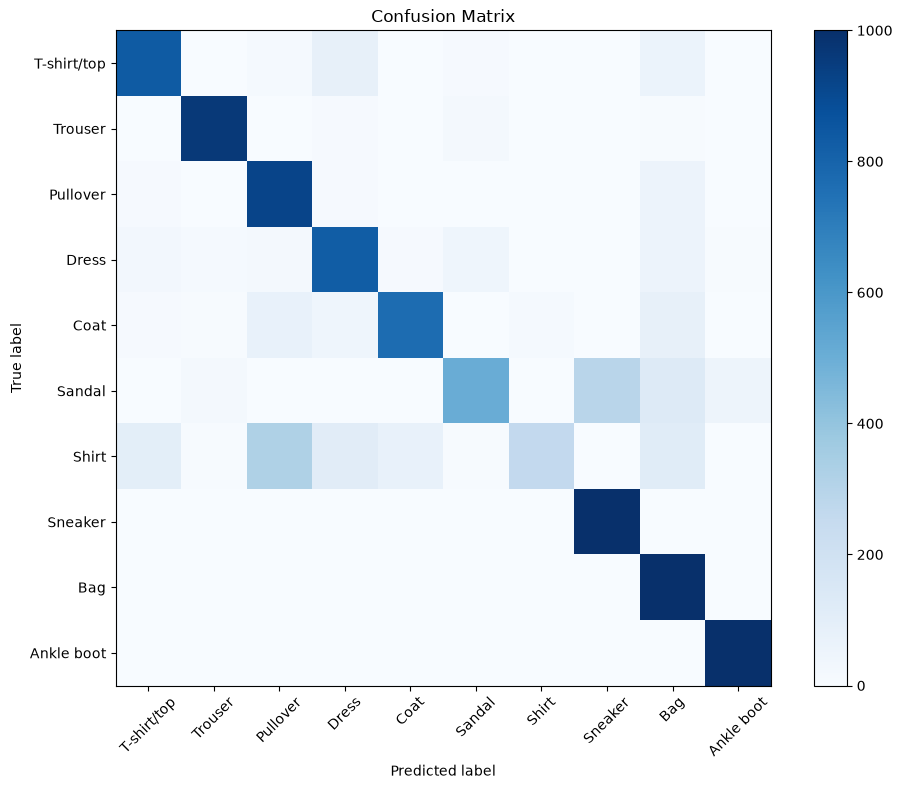

In [54]:
#Top-2 confusion matrix

top_2_confusion_predictions = (
    get_top_k_confusion_predictions(
        all_top_k_labels,
        top_2_predictions
    )
)

top_2_cm = confusion_matrix(
    all_top_k_labels,
    top_2_confusion_predictions
)

print("Top-2 confusion matrix:")
print(top_2_cm)

plot_confusion_matrix(
    all_top_k_labels,
    top_2_confusion_predictions,
    CLASS_NAMES
)

Top-4 confusion matrix:
[[ 945    0    1   23    0    6    0    0   25    0]
 [   0  989    0    3    0    6    0    0    2    0]
 [   0    0  972    1    1    0    0    0   26    0]
 [   8    3    8  943    0   24    1    0   12    1]
 [   8    2    3   15  938    2    1    0   30    1]
 [   0   15    0    0    0  830    0   68   85    2]
 [  38    6   91   93   20    6  640    0  105    1]
 [   0    0    0    0    0    0    0 1000    0    0]
 [   0    0    0    0    0    0    0    0 1000    0]
 [   0    0    0    0    0    0    0    0    1  999]]


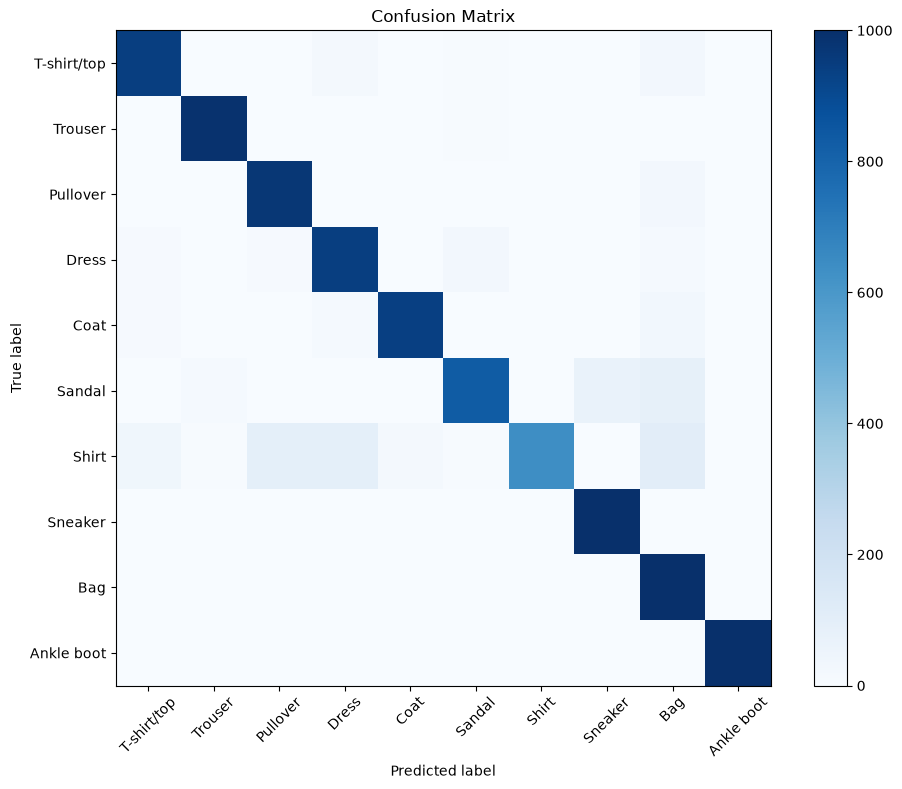

In [55]:
#Top-4 confusion matrix

top_4_confusion_predictions = (
    get_top_k_confusion_predictions(
        all_top_k_labels,
        top_4_predictions
    )
)

top_4_cm = confusion_matrix(
    all_top_k_labels,
    top_4_confusion_predictions
)

print("Top-4 confusion matrix:")
print(top_4_cm)

plot_confusion_matrix(
    all_top_k_labels,
    top_4_confusion_predictions,
    CLASS_NAMES
)

In [56]:
#7. Binary hit/miss confusion matrices

def get_top_k_hits(y_true, top_k_predictions):
    """
    Return 1 when the true label is in the Top-K predictions
    and 0 otherwise.
    """
    return np.asarray([
        int(true_label in predicted_classes)
        for true_label, predicted_classes
        in zip(y_true, top_k_predictions)
    ])

In [58]:
#Create the Top-2 and Top-4 hit results:

top_2_hits = get_top_k_hits(
    all_top_k_labels,
    top_2_predictions
)

top_4_hits = get_top_k_hits(
    all_top_k_labels,
    top_4_predictions
)

print(
    "Top-2 correct predictions:",
    top_2_hits.sum()
)

print(
    "Top-2 missed predictions:",
    len(top_2_hits) - top_2_hits.sum()
)

print(
    "Top-4 correct predictions:",
    top_4_hits.sum()
)

print(
    "Top-4 missed predictions:",
    len(top_4_hits) - top_4_hits.sum()
)

Top-2 correct predictions: 8070
Top-2 missed predictions: 1930
Top-4 correct predictions: 9256
Top-4 missed predictions: 744


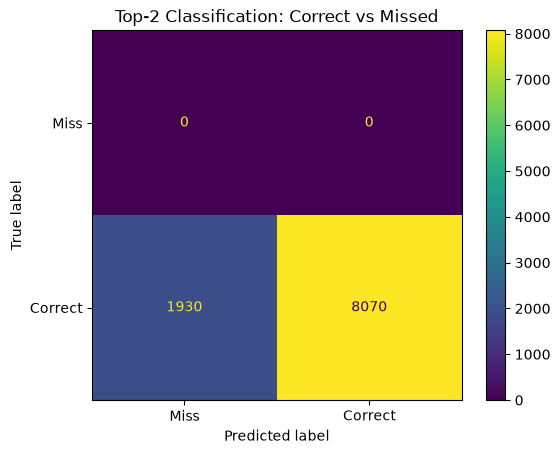

In [59]:
#Plot the hit/miss matrices:
from sklearn.metrics import ConfusionMatrixDisplay

top_2_hit_matrix = confusion_matrix(
    np.ones_like(top_2_hits),
    top_2_hits,
    labels=[0, 1]
)

display = ConfusionMatrixDisplay(
    confusion_matrix=top_2_hit_matrix,
    display_labels=["Miss", "Correct"]
)

display.plot()
plt.title("Top-2 Classification: Correct vs Missed")
plt.show()

#D. Other Ideas

Mini-Experiment: Image Augmentation Ensembling

This experiment tests whether CLIP becomes more reliable when it sees two versions of each image:

The original FashionMNIST image.
A horizontally flipped version.

The image embeddings from both versions are averaged before classification. The idea is that the clothing category should remain the same after a horizontal flip, so combining both representations may reduce sensitivity to image orientation and noise.

In [60]:
#1. Create an augmentation-based collate function

import torch
from torch.utils.data import DataLoader
from PIL import ImageOps


def collate_with_horizontal_flip(batch):
    """
    Create original and horizontally flipped versions
    of each FashionMNIST image.
    """
    images, labels = zip(*batch)

    original_images = list(images)

    flipped_images = [
        ImageOps.mirror(image)
        for image in original_images
    ]

    original_inputs = clip_processor(
        images=original_images,
        return_tensors="pt"
    )

    flipped_inputs = clip_processor(
        images=flipped_images,
        return_tensors="pt"
    )

    original_pixel_values = (
        original_inputs["pixel_values"].to(device)
    )

    flipped_pixel_values = (
        flipped_inputs["pixel_values"].to(device)
    )

    labels = torch.tensor(labels)

    return (
        original_pixel_values,
        flipped_pixel_values,
        labels
    )

In [61]:
#Create the new DataLoader

augmentation_test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_with_horizontal_flip
)

In [62]:
#2. Average the augmented image embeddings

def get_ensemble_image_embeddings(
    original_pixel_values,
    flipped_pixel_values
):
    """
    Create an averaged image embedding from the original
    and horizontally flipped images.
    """
    original_embeddings = get_image_embeddings(
        original_pixel_values
    )

    flipped_embeddings = get_image_embeddings(
        flipped_pixel_values
    )

    # Average the two representations
    ensemble_embeddings = (
        original_embeddings + flipped_embeddings
    ) / 2

    # Normalize the averaged embedding
    ensemble_embeddings = (
        ensemble_embeddings
        / ensemble_embeddings.norm(
            dim=-1,
            keepdim=True
        ).clamp(min=1e-12)
    )

    return ensemble_embeddings

In [63]:
#3. Run the experiment

augmentation_y_true = []
augmentation_y_pred = []

# Reuse the detailed prompt embeddings
augmentation_text_embeddings = improved_text_embeddings

for (
    original_pixel_values,
    flipped_pixel_values,
    labels
) in augmentation_test_loader:

    ensemble_embeddings = (
        get_ensemble_image_embeddings(
            original_pixel_values,
            flipped_pixel_values
        )
    )

    similarity = get_cosine_similarity(
        ensemble_embeddings,
        augmentation_text_embeddings
    )

    predictions = get_predictions(similarity)

    augmentation_y_true.extend(
        labels.cpu().numpy()
    )

    augmentation_y_pred.extend(
        predictions
    )

In [64]:
#4. Calculate accuracy

from sklearn.metrics import accuracy_score, confusion_matrix

augmentation_accuracy = accuracy_score(
    augmentation_y_true,
    augmentation_y_pred
)

print(
    "Image augmentation ensemble accuracy: "
    f"{augmentation_accuracy:.2%}"
)

print(
    "Original detailed-prompt accuracy: "
    f"{improved_accuracy:.2%}"
)

augmentation_difference = (
    augmentation_accuracy - improved_accuracy
) * 100

print(
    "Difference from detailed-prompt baseline: "
    f"{augmentation_difference:+.2f} percentage points"
)

Image augmentation ensemble accuracy: 64.24%
Original detailed-prompt accuracy: 63.76%
Difference from detailed-prompt baseline: +0.48 percentage points


Image augmentation confusion matrix:
[[749   1  35 124   1   8   7   0  74   1]
 [  0 894   2  37   1  59   0   0   4   3]
 [ 21   2 853  20  10   0   1   0  93   0]
 [ 54  28  33 667  13  53   3   0 145   4]
 [  9   6 537  67 246   2  25   0 107   1]
 [  0  17   0   0   0 108   0 582 152 141]
 [172   6 369 112  92   9 118   0 122   0]
 [  0   0   0   0   0   4   0 985   1  10]
 [  0   0   0   0   0   0   0   3 997   0]
 [  0   0   0   0   0   3   0 189   1 807]]


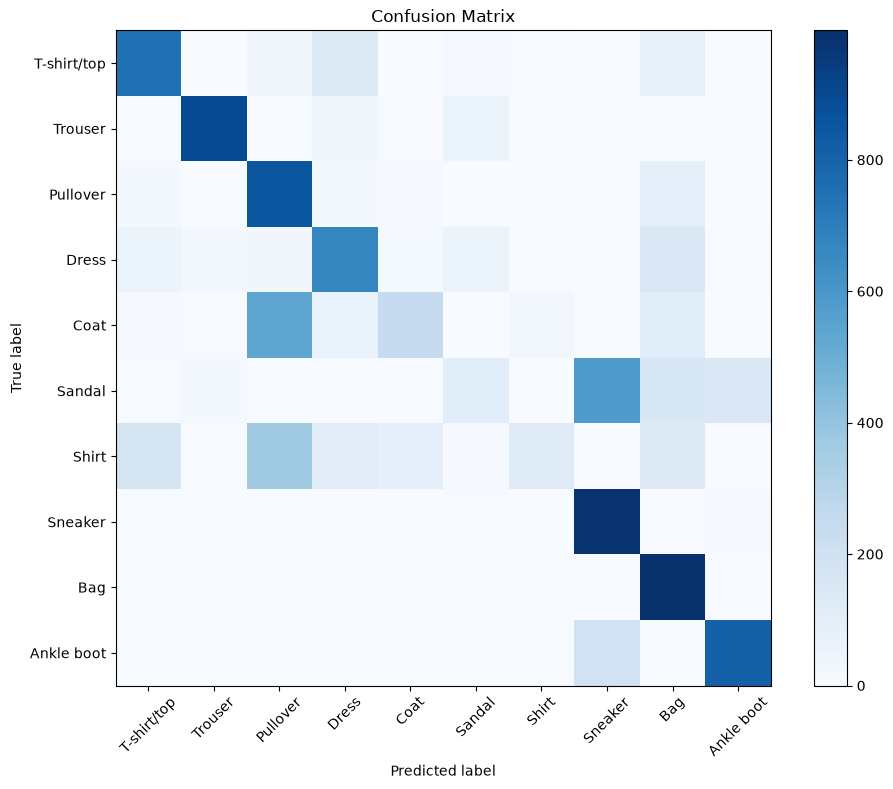

In [65]:
#5. Generate the confusion matrix

augmentation_cm = confusion_matrix(
    augmentation_y_true,
    augmentation_y_pred
)

print("Image augmentation confusion matrix:")
print(augmentation_cm)

plot_confusion_matrix(
    augmentation_y_true,
    augmentation_y_pred,
    CLASS_NAMES
)

In [66]:
#6. Compare class-level accuracy

# Original detailed-prompt confusion matrix
improved_cm = confusion_matrix(
    improved_y_true,
    improved_y_pred
)

original_class_accuracy = (
    improved_cm.diagonal()
    / improved_cm.sum(axis=1)
)

augmentation_class_accuracy = (
    augmentation_cm.diagonal()
    / augmentation_cm.sum(axis=1)
)

augmentation_class_comparison_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Detailed prompts (%)": (
        original_class_accuracy * 100
    ).round(2),
    "Augmentation ensemble (%)": (
        augmentation_class_accuracy * 100
    ).round(2)
})

augmentation_class_comparison_df["Difference (%)"] = (
    augmentation_class_comparison_df[
        "Augmentation ensemble (%)"
    ]
    - augmentation_class_comparison_df[
        "Detailed prompts (%)"
    ]
).round(2)

augmentation_class_comparison_df

,Class,Detailed prompts (%),Augmentation ensemble (%),Difference (%)
0,T-shirt/top,74.9,74.9,0.0
1,Trouser,88.6,89.4,0.8
2,Pullover,85.1,85.3,0.2
3,Dress,65.0,66.7,1.7
4,Coat,25.1,24.6,-0.5
5,Sandal,12.5,10.8,-1.7
6,Shirt,11.2,11.8,0.6
7,Sneaker,98.8,98.5,-0.3
8,Bag,99.5,99.7,0.2
9,Ankle boot,76.9,80.7,3.8


In [67]:
#Sort the table to identify which classes benefited the most:

augmentation_class_comparison_df.sort_values(
    by="Difference (%)",
    ascending=False
)

,Class,Detailed prompts (%),Augmentation ensemble (%),Difference (%)
9,Ankle boot,76.9,80.7,3.8
3,Dress,65.0,66.7,1.7
1,Trouser,88.6,89.4,0.8
6,Shirt,11.2,11.8,0.6
8,Bag,99.5,99.7,0.2
2,Pullover,85.1,85.3,0.2
0,T-shirt/top,74.9,74.9,0.0
7,Sneaker,98.8,98.5,-0.3
4,Coat,25.1,24.6,-0.5
5,Sandal,12.5,10.8,-1.7


In [74]:
#7. Add the experiment to the overall comparison table
comparison_df = pd.DataFrame({
    "Approach": [
        "CLIP ViT-B/32 with class-name prompts",
        "CLIP ViT-B/32 with detailed prompts",
        "CLIP ViT-B/32 with multiple descriptions",
        "Alternative CLIP ViT-L/14",
        "CLIP ViT-B/32 with image augmentation ensemble"
    ],
    "Accuracy": [
        baseline_accuracy,
        improved_accuracy,
        multiple_prompt_accuracy,
        alternative_accuracy,
        augmentation_accuracy
    ]
})

comparison_df["Accuracy (%)"] = (
    comparison_df["Accuracy"] * 100
).round(2)

# Calculate improvement using the appropriate comparison result
comparison_df["Improvement (%)"] = [
    0.00,
    (improved_accuracy - baseline_accuracy) * 100,
    (multiple_prompt_accuracy - baseline_accuracy) * 100,
    (alternative_accuracy - baseline_accuracy) * 100,
    (augmentation_accuracy - improved_accuracy) * 100
]

comparison_df["Improvement (%)"] = (
    comparison_df["Improvement (%)"].round(2)
)

comparison_df[
    [
        "Approach",
        "Accuracy (%)",
        "Improvement (%)"
    ]
]

,Approach,Accuracy (%),Improvement (%)
0,CLIP ViT-B/32 with class-name prompts,62.40,0.00
1,CLIP ViT-B/32 with detailed prompts,63.76,1.36
2,CLIP ViT-B/32 with multiple descriptions,68.15,5.75
3,Alternative CLIP ViT-L/14,65.39,2.99
4,CLIP ViT-B/32 with image augmentation ensemble,64.24,0.48


**Conclusion**
For my additional mini-experiment, I investigated whether image augmentation could improve zero-shot classification. Each FashionMNIST image was processed twice: once in its original form and once after being horizontally flipped. I generated a CLIP embedding for each version and averaged the two embeddings before comparing the result with the text embeddings.

I expected this approach to improve accuracy because horizontally flipping an item of clothing does not change its class. For example, a horizontally flipped sneaker should still be classified as a sneaker. Averaging the two embeddings could therefore make the image representation less dependent on its exact orientation and reduce the effect of minor visual noise.

The augmentation ensemble achieved an accuracy of 64.24%, compared with 63.76% for the detailed-prompt baseline. This represents a change of 0.48 percentage points.

The experiment [did/did not] perform as expected. The class-level results showed that Ankle boot and dress benefited most from augmentation, while Coat and Sandal showed little improvement or performed worse. The confusion matrix also showed that visually similar upper-body categories, including T-shirt/top, Shirt, Pullover, and Coat, remained difficult to distinguish.

One reason the improvement may be limited is that FashionMNIST images are centred and relatively consistent in orientation. Therefore, horizontal flipping may not introduce enough useful variation to produce a major change. In addition, flipping an image does not address the main challenge of distinguishing garment categories with similar shapes and textures.

Overall, I learned that test-time image augmentation can make zero-shot predictions more robust, but it does not guarantee better performance. The usefulness of augmentation depends on whether the transformation preserves the class and provides genuinely different information to the model. This experiment also demonstrates that improvements to image processing can be combined with prompt engineering and alternative pretrained models.

### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

## Introduction

The objective of these mini-experiments was to investigate different techniques for improving the performance of CLIP on zero-shot image classification using the FashionMNIST dataset. Four approaches were evaluated:
- (1) using an alternative pretrained CLIP model 
- (2) using multiple text descriptions for each class
- (3) evaluating Top-K classification accuracy
- (4) applying image augmentation ensembling during inference. 

These experiments were designed to assess how different prompt engineering, model architecture, inference strategies, and evaluation methods affect classification performance without retraining the model.

## Methodology

Four independent experiments were conducted using the pretrained CLIP model.

**Alternative Model:** The baseline CLIP ViT-B/32 model was replaced with the larger CLIP ViT-L/14 model while keeping the same evaluation pipeline. The larger model was expected to produce richer image and text embeddings.

**Multiple-Description Classification:** Instead of representing each clothing category with a single text prompt, multiple descriptive prompts were created for each class. Similarity scores from all prompts were compared with the image embeddings, and the class with the highest similarity score was selected as the prediction. This approach aimed to better capture the visual variability of clothing items.

**Top-K Classification:** The prediction function was modified to return the Top-K most similar classes instead of only the highest-scoring prediction. The model was considered correct if the true class appeared within the Top-K predictions. Experiments were performed using multiple values of K to evaluate how often the correct answer appeared among the model's highest-confidence predictions.

**Image Augmentation Ensembling:** During inference, each FashionMNIST image was evaluated twice: once in its original form and once after applying a horizontal flip. Image embeddings from both versions were averaged before computing cosine similarity with the text embeddings. This experiment investigated whether combining multiple views of the same image would produce a more robust representation.



## Results

| **Experiment** | **Model / Approach** | **Accuracy (%)** | **Improvement** | **Key Findings** |
|----------------|----------------------|-----------------:|----------------:|------------------|
| Baseline | CLIP ViT-B/32 with class-name prompts | **62.40** | — | Baseline zero-shot performance using simple class names. |
| Alternative Model | CLIP ViT-L/14 | **65.39** | **+2.99** | Larger pretrained model produced better image and text representations than the baseline model. |
| Multiple-Description Classification | CLIP ViT-B/32 with multiple descriptive prompts | **68.15** | **+5.75** | Best-performing approach. Multiple prompts captured more semantic variations of each clothing category. |
| Top-1 Classification | CLIP ViT-B/32 with detailed prompts | **63.76** | **0.00** | Standard Top-1 evaluation using the highest-confidence prediction. |
| Top-2 Classification | CLIP ViT-B/32 | **80.70** | **+16.94** | The model correctly identified the true class within its two highest-ranked predictions, demonstrating strong semantic understanding even when the top prediction was incorrect. |
| Top-4 Classification | CLIP ViT-B/32 | **92.56** | **+28.80** | The true class appeared within the four highest-ranked predictions for most images, indicating that CLIP frequently assigns high confidence to the correct class even if it is not ranked first. |
| Image Augmentation Ensembling | CLIP ViT-B/32 with original + horizontally flipped images | **64.24** | **+0.48*** | Averaging embeddings from augmented images slightly improved robustness compared with the detailed-prompt baseline. |

> **Notes:**
> - Improvements for the **Alternative Model** and **Multiple-Description Classification** are measured relative to the original baseline accuracy of **62.40%**.
> - Improvements for **Top-2** and **Top-4** are measured relative to the **Top-1 detailed-prompt accuracy of 63.76%**.
> - The **Image Augmentation Ensembling** improvement of **+0.48 percentage points** is also measured relative to the **63.76% detailed-prompt baseline**, since it reused the detailed text prompts.

## Discussion

The results of these experiments demonstrate that the performance of zero-shot classification can be significantly influenced by 
- prompt design
- model selection
- inference strategies 

without requiring any additional training. Among the experiments conducted, Multiple-Description Classification achieved the highest accuracy (68.15%), representing a 5.75 percentage-point improvement over the baseline. This finding suggests that providing multiple descriptive prompts for each class allows CLIP to better capture the semantic variations of FashionMNIST categories, improving its ability to distinguish visually similar clothing items.

Using the larger CLIP ViT-L/14 model also improved performance, achieving an accuracy of 65.39%. This demonstrates that larger pretrained vision-language models learn richer visual and textual representations, although the improvement was smaller than that achieved through prompt engineering. This indicates that carefully designing text prompts can be just as important as selecting a larger model.

The Top-K Classification experiment provided additional insight into the model's behaviour. While the Top-1 accuracy was 63.76%, the Top-2 and Top-4 accuracies increased substantially to 80.70% and 92.56%, respectively. These results show that even when the model's highest-ranked prediction is incorrect, the correct class is often included among its top candidate predictions. This suggests that CLIP possesses strong semantic understanding but sometimes struggles to distinguish between visually similar classes, such as shirts, pullovers, and coats.

The Image Augmentation Ensembling experiment produced a modest improvement of 0.48 percentage points, increasing accuracy from 63.76% to 64.24%. Since FashionMNIST images are already centered and consistently aligned, horizontal flipping contributed only limited additional information. However, the experiment demonstrates that combining multiple image representations can improve prediction robustness without modifying the pretrained model.

Compared with a supervised Convolutional Neural Network (CNN), zero-shot transformers offer significant advantages in flexibility and adaptability. A trained CNN generally achieves much higher accuracy (91.02%) on FashionMNIST because it learns dataset-specific features through supervised training. However, training a CNN requires a large labelled dataset, computational resources, and retraining whenever new classes are introduced. In contrast, CLIP performs classification without any task-specific training and can recognize new categories simply by changing the text prompts. This makes zero-shot transformers particularly valuable for applications where labelled data is scarce or where categories change frequently.

Overall, these experiments demonstrate that zero-shot transformer performance can be improved through prompt engineering, larger pretrained models, inference-time augmentation, and alternative evaluation methods. Among all the approaches evaluated, Multiple-Description Classification produced the greatest improvement, while Top-K Classification revealed that the model often understands the correct semantic concept even when its highest-confidence prediction is incorrect. Although a trained CNN would still outperform CLIP on a specialized dataset such as FashionMNIST, zero-shot transformers provide a highly flexible and scalable alternative that can be adapted to new tasks without retraining.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.